# 📉 Análise de Devoluções e Ralo Financeiro

## Objetivo de Negócio
Após descobrirmos que nossa margem de preços na ponta é altíssima (>50%), precisamos investigar se estamos perdendo dinheiro através de **Devoluções**. 

Esta análise responde:
1. **Motivos principais:** Por que os clientes estão devolvendo nossos produtos?
2. **Os Verdadeiros Vilões:** Quais SKUs têm alto volume de devolução (prejuízo de frete/estorno)?

In [2]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

con = duckdb.connect()
df_dev = con.execute("SELECT * FROM '../data/processed/fato_devolucoes.parquet'").df()
df_vendas = con.execute("SELECT * FROM '../data/processed/fato_vendas.parquet'").df()

print(f"Foram carregados {len(df_dev):,} itens devolvidos em todo o histórico válido.")

Foram carregados 1,276 itens devolvidos em todo o histórico válido.


### 1. Quais são os motivos principais de devolução?

C:\Users\ppfsa\AppData\Local\Temp\ipykernel_23312\1075347076.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=motivos, y='return_reason', x='return_quantity', palette='Reds_r')


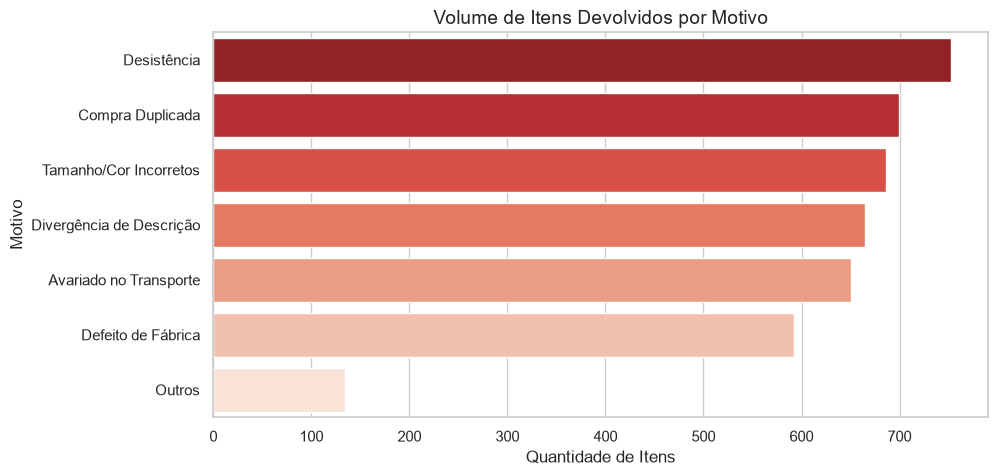

In [3]:
motivos = df_dev.groupby('return_reason')['return_quantity'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=motivos, y='return_reason', x='return_quantity', palette='Reds_r')
plt.title('Volume de Itens Devolvidos por Motivo', fontsize=14)
plt.xlabel('Quantidade de Itens')
plt.ylabel('Motivo')
plt.show()

### 2. Identificando os SKUs ofensores (Os Vilões)
Vamos calcular a Taxa de Devolução por Produto: (Quantidade Devolvida / Quantidade Vendida).

In [4]:
# Somando vendas totais por SKU
vendas_sku = df_vendas.groupby('sku')['quantity'].sum().reset_index().rename(columns={'quantity': 'qty_vendida'})
# Somando devoluções por SKU
dev_sku = df_dev.groupby(['sku', 'product_name']).agg({
    'return_quantity': 'sum',
    'item_refund_total': 'sum'
}).reset_index()

# Cruzando os dados
df_analise = pd.merge(vendas_sku, dev_sku, on='sku', how='inner')
df_analise['taxa_devolucao_pct'] = (df_analise['return_quantity'] / df_analise['qty_vendida']) * 100

# Filtrando apenas produtos com amostragem relevante (> 50 unidades vendidas no histórico)
df_analise = df_analise[df_analise['qty_vendida'] > 50]

viloes = df_analise.sort_values('taxa_devolucao_pct', ascending=False).head(10)

display(viloes.style.format({
    'taxa_devolucao_pct': '{:.2f}%',
    'item_refund_total': 'R$ {:,.2f}'
}))

,sku,qty_vendida,product_name,return_quantity,item_refund_total,taxa_devolucao_pct
731,LHN-998857,616,Tinta Antifouling 6853,25.000000,"R$ 36,918.00",4.06%
143,LHN-199057,689,Tinta Antifouling 1614,21.000000,"R$ 2,118.09",3.05%
536,LHN-741648,872,Motor de Popa 5331,26.000000,"R$ 32,753.25",2.98%
43,LHN-051460,740,Bateria Náutica 2558,22.000000,"R$ 11,467.17",2.97%
73,LHN-100901,711,Motor de Popa 2175,20.000000,"R$ 52,231.60",2.81%
1,LHN-010981,710,Defensa Náutica 1161,19.000000,"R$ 50,890.72",2.68%
510,LHN-698603,740,Defensa Náutica 5959,19.000000,"R$ 27,750.24",2.57%
613,LHN-834456,678,Bateria Náutica 684,17.000000,"R$ 3,527.20",2.51%
726,LHN-988025,758,Sonar Transducer 4154,19.000000,"R$ 48,874.83",2.51%
320,LHN-453118,723,Colete Salva-Vidas 9810,18.000000,"R$ 3,374.44",2.49%


### 3. Conclusão Executiva e Framework de Decisão

**Fato Observado:** 
*Desistência, Compras Duplicadas, Tamanho/Cores Incorretas, Divergência na Descrição, Avaria no Transporte e Defeitos de Fábrica compõem os principais motivos de devolução na base histórica tratada.*

**Hipótese:**
*Temos dois gargalos sistêmicos claros atuando simultaneamente:\n1. **Fricção Digital:** Desistências, compras duplicadas e itens incorretos apontam para uma interface de e-commerce defeituosa (provável falha técnica no checkout ou informações pobres na página do produto).\n2. **Fricção Física:** Avarias e defeitos evidenciam problemas graves no manejo logístico (da linha de produção do fornecedor até o envio via transportadora).*

**Recomendação:**
*Ação Imediata (Produto): Escalar para o time de UX/UI uma revisão urgente do fluxo do carrinho (para mitigar compras duplicadas) e melhoria nas tabelas de medidas e descrições.\nAção Imediata (Logística): Iniciar auditoria de qualidade nos SKUs que lideram a lista de vilões, reavaliar SLA dos atuais parceiros de frete e buscar no mercado opções de entrega com menor índice de quebra no transporte.*